<a href="https://colab.research.google.com/github/mizukizzaaaiii/Game_Jam_Project/blob/main/Brain_Tumor_MRI_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection from MRI Scans:

This notebook guides you through the work of building, training, and evaluating a Convolutional Neural Network (CNN) model for detecting and classifying brain tumors from MRI scans.

## Table of Contents

1.  **[Define the Problem](#scrollTo=b0250df2)**
    *   _What is this project about?_
    *   We outline the main goal (tumor detection/classification), identify it as a classification task, and define what a successful outcome would look like.

2.  **[Data Loading and Preprocessing](#scrollTo=82c80be0)**
    *   _How do we get and prepare our image data?_
    *   This section explains how image datasets are structured for machine learning. We then use `kagglehub` to download the brain MRI dataset and `ImageDataGenerator` to load our images efficiently, creating training, validation, and test datasets. It also includes an initial visualization of some loaded images.

3.  **[Data Augmentation](#scrollTo=886d3be2)**
    *   _How do we make our model more robust and prevent overfitting?_
    *   Here, we introduce the concept of data augmentation – applying random transformations (like flips, rotations, zooms) to our training images. This artificially expands our dataset and helps the model generalize better to new, unseen MRI scans. The `ImageDataGenerator` also handles this.

4.  **[Build the Transfer Learning Model (MobileNetV2)](#scrollTo=07b34120)**
    *   _What kind of neural network are we using?_
    *   This section focuses on defining our transfer learning model using a pre-trained MobileNetV2 base and a custom classification head. The model's summary is displayed.

5.  **[Compile the Model](#scrollTo=0c6b9085)**
    *   _How do we prepare the model for training?_
    *   Before training, we configure the model by specifying the `optimizer` (how the model learns), the `loss function` (what the model tries to minimize), and the `metrics` (how we measure its performance, like accuracy).

6.  **[Train the Model (Phase 1: Head Training)](#scrollTo=9ab1c9b1)**
    *   _How does the model learn from the data?_
    *   This is where the initial learning process happens. We train only the custom classification head of our transfer learning model, keeping the MobileNetV2 base frozen.

7.  **[Visualize Model Performance (Phase 1)](#scrollTo=f87c4fce)**
    *   _How well did our model learn in the first phase?_
    *   After the initial training, we plot the training and validation accuracy and loss over the epochs to evaluate the head training performance.

8.  **[Implement Transfer Learning & Fine-tuning](#scrollTo=a326e175)**
    *   _How can we make our model even better using advanced techniques?_
    *   This section explains the strategy for improving accuracy by leveraging a pre-trained model and then fine-tuning its layers.

9.  **[Corrected Fine-tuning (Phase 2: Base Model Fine-tuning)](#scrollTo=fba274b1)**
    *   _How do we continue training to achieve higher accuracy?_
    *   We reload the best model from Phase 1, unfreeze a portion of the MobileNetV2 base, re-compile with a lower learning rate, and continue training.

10. **[Visualize Combined Performance](#scrollTo=243f7490)**
    *   _How well did the model learn across both training phases?_
    *   Plots showing the combined training and validation accuracy and loss from both head training and fine-tuning phases.

11. **[Final Evaluation on Test Dataset](#scrollTo=ad211353)**
    *   _What is the final performance of our fine-tuned model on unseen data?_
    *   The model's performance is evaluated on the dedicated test dataset.

## Define the Problem

**What is the goal?**  
To train a machine learning model that can analyze brain MRI scans and accurately classify whether a scan shows a tumor or no tumor (or identify specific tumor types like Glioma, Meningioma, or Pituitary)

**What type of task is this?**  
Classification (predicting discrete labels: Tumor vs. No Tumor)

**What would a successful result look like?**
- Model accuracy above 85% on unseen test images
- An interactive web app (built with Streamlit or Gradio) where a user can upload an MRI scan and get an instant prediction

## One-Line Project Summary

> *"I want to build an interactive AI tool that can detect and classify brain tumors from MRI scans to assist with fast medical imaging analysis."*

## Data Loading and Preprocessing

For image classification tasks, datasets are often organized into directories where each subdirectory represents a class. For example, your dataset might look like this:

```
my_mri_dataset/
  train/
    tumor/
      image1.jpg
      image2.png
      ...
    no_tumor/
      imageA.jpg
      imageB.png
      ...
  validation/
    tumor/
      imageX.jpg
      ...
    no_tumor/
      imageY.jpg
      ...
  test/
    tumor/
      imageZ.jpg
      ...
    no_tumor/
      imageW.jpg
      ...
```

We use `tf.keras.preprocessing.image.ImageDataGenerator` to efficiently load these images from directories, apply real-time data augmentation (for the training set), and create batches for training, validation, and testing. This function automatically infers labels from the directory names.

You'll need to specify the path to your dataset, the target image size, and the batch size. Our dataset is located at `/kaggle/input/brain-tumor-mri-dataset`.

In [1]:
import tensorflow as tf
import kagglehub
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Download the Kaggle dataset
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

# Define parameters for loading the dataset (updated target_size to 224, 224 as requested)
IMAGE_SIZE = (224, 224) # Updated IMAGE_SIZE to (224, 224) for MobileNetV2
BATCH_SIZE = 32

# Set the root path for the dataset.
dataset_root = path

# --- Using ImageDataGenerator for data loading and augmentation as requested ---
# Data augmentation for training images
train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest',
    rescale=None # MobileNetV2 preprocess_input layer will handle scaling
)

# No augmentation for validation/test sets, but still use ImageDataGenerator for consistent loading
val_test_datagen = ImageDataGenerator(rescale=None)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_root, 'Training'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_root, 'Testing'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle validation data
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_root, 'Testing'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print("Class names loaded from generator:", class_names)
print(f"Number of classes: {num_classes}")

print("ImageDataGenerator-based data loading and augmentation pipeline initialized.")

# --- Commenting out previous tf.keras.utils.image_dataset_from_directory calls ---
# # Load the training dataset
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     os.path.join(dataset_root, 'Training'),
#     labels='inferred',
#     label_mode='categorical', # Use 'binary' for 2 classes, 'categorical' for >2 classes, 'int' for integer labels
#     image_size=IMAGE_SIZE,
#     interpolation='nearest',
#     batch_size=BATCH_SIZE,
#     shuffle=True
# )

# # Load the validation dataset (using 'Testing' as a validation set for now)
# validation_ds = tf.keras.utils.image_dataset_from_directory(
#     os.path.join(dataset_root, 'Testing'),
#     labels='inferred',
#     label_mode='categorical',
#     image_size=IMAGE_SIZE,
#     interpolation='nearest',
#     batch_size=BATCH_SIZE,
#     shuffle=False # Typically no need to shuffle validation/test sets
# )

# # Load the test dataset (also using 'Testing' as a test set for now)
# test_ds = tf.keras.utils.image_dataset_from_directory(
#     os.path.join(dataset_root, 'Testing'),
#     labels='inferred',
#     label_mode='categorical',
#     image_size=IMAGE_SIZE,
#     interpolation='nearest',
#     batch_size=BATCH_SIZE,
#     shuffle=False
# )

# # print(f"Found {len(train_ds) * BATCH_SIZE} training images belonging to {len(train_ds.class_names)} classes.")
# # print(f"Found {len(validation_ds) * BATCH_SIZE} validation images belonging to {len(validation_ds.class_names)} classes.")
# # print(f"Found {len(test_ds) * BATCH_SIZE} test images belonging to {len(test_ds.class_names)} classes.")

# # You can also get the class names:
# # class_names = train_ds.class_names
# # print("Class names:", class_names)

# # You might want to visualize a batch to ensure it loaded correctly
# import matplotlib.pyplot as plt

# # plt.figure(figsize=(10, 10))
# # for images, labels in train_ds.take(1):
# #     for i in range(9):
# #         ax = plt.subplot(3, 3, i + 1)
# #         plt.imshow(images[i].numpy().astype("uint8"))
# #         plt.title(class_names[tf.argmax(labels[i])])
# #         plt.axis("off")
# #     plt.show()

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class names loaded from generator: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
ImageDataGenerator-based data loading and augmentation pipeline initialized.


### Data Augmentation

**What is Data Augmentation?**
Data augmentation is a technique used to artificially increase the size and diversity of a training dataset by applying various random transformations to the original images. For example, for an image of a brain MRI, we might create new training examples by rotating the image slightly, flipping it horizontally, or adjusting its brightness.

**Why is it important?**
1.  **Prevents Overfitting**: By exposing the model to a wider variety of slightly altered images, it learns to generalize better and becomes less sensitive to specific features of the original training samples. This reduces overfitting, where a model performs well on training data but poorly on unseen data.
2.  **Improves Model Robustness**: It helps the model become more resilient to variations in real-world data, such as different orientations, lighting conditions, or minor imperfections in image capture.
3.  **Increases Dataset Size**: Especially useful when the original dataset is small, as it effectively expands the number of training examples without requiring new data collection.

We implement data augmentation directly within the `ImageDataGenerator` by specifying parameters such as `rotation_range`, `horizontal_flip`, `zoom_range`, `brightness_range`, `width_shift_range`, `height_shift_range`, and `vertical_flip` for the training data. The validation and test data generators do not use these augmentation parameters to ensure an unbiased evaluation.

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


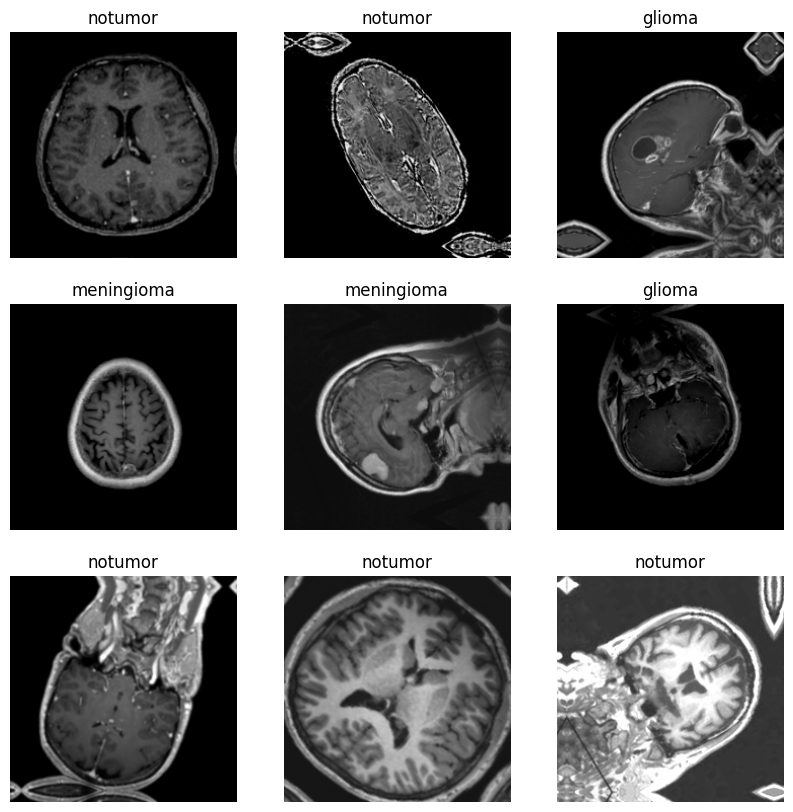

Data augmentation pipeline defined and applied to training data.


In [3]:
import numpy as np
import tensorflow as tf
import os

# Re-load train_ds and validation_ds as they were removed/commented out in a previous cell.
# This assumes IMAGE_SIZE, BATCH_SIZE, and dataset_root are defined globally or in an earlier cell,
# which is confirmed by the kernel state.

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'Training'),
    labels='inferred',
    label_mode='categorical', # Use 'categorical' as labels are one-hot encoded for multi-class classification
    image_size=IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load the validation dataset
validation_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'Testing'), # Using 'Testing' as validation, consistent with previous code
    labels='inferred',
    label_mode='categorical',
    image_size=IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Also re-define class_names for consistency, as it's used in visualization
class_names = train_ds.class_names

# Define the data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # Randomly flip images horizontally and vertically
    tf.keras.layers.RandomRotation(0.2), # Randomly rotate images by up to 20% of a full circle (360 degrees)
    tf.keras.layers.RandomZoom(0.2), # Randomly zoom images by up to 20%
    tf.keras.layers.RandomContrast(0.2), # Randomly adjust the contrast by up to 20%
    tf.keras.layers.RandomBrightness(0.2), # Randomly adjust the brightness by up to 20%
    tf.keras.layers.GaussianNoise(0.1) # Add Gaussian noise with a standard deviation of 0.1
])

# Apply data augmentation to the training dataset
# Note: Data augmentation should only be applied to the training dataset to prevent data leakage.
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Optimize the training dataset for performance
augmented_train_ds = augmented_train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Optimize the validation dataset for performance
validation_ds = validation_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Let's visualize some augmented images to see the effects
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in augmented_train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Ensure image data type is correct for imshow (uint8) and clip values to 0-255 range
        plt.imshow(images[i].numpy().clip(0, 255).astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i])])
        plt.axis("off")
    plt.show()

print("Data augmentation pipeline defined and applied to training data.")


Data augmentation for the training set is handled by `ImageDataGenerator` as specified in the data loading section.

### Build the Transfer Learning Model with MobileNetV2

Instead of building a CNN from scratch, we leverage **Transfer Learning** using a pre-trained **MobileNetV2** model. This approach reuses knowledge gained from training on a massive dataset (ImageNet) and adapts it to our specific task of brain tumor classification. MobileNetV2 is an efficient convolutional neural network designed for mobile and embedded vision applications, making it suitable for this task.

Here's how our model is constructed:

1.  **`Input` Layer**: Defines the expected shape of our input images (224x224 pixels with 3 color channels).

2.  **`Lambda(mobilenet_v2.preprocess_input)` Layer**: MobileNetV2 models expect input pixel values to be in a specific range (-1 to 1). This `Lambda` layer applies the necessary preprocessing (scaling pixels from 0-255 to -1 to 1) to our images.

3.  **`MobileNetV2` Base Model**: We load the pre-trained MobileNetV2 model, *excluding* its original classification head (`include_top=False`). The `weights='imagenet'` argument ensures we use the weights learned from the ImageNet dataset. Initially, all layers of this base model are set to `trainable=False` to act as a fixed feature extractor.

4.  **`GlobalAveragePooling2D()`**: After the MobileNetV2 base extracts features, this layer reduces the spatial dimensions of the feature maps to a single feature vector for each feature map by taking the average across all locations. This helps simplify the output of the convolutional layers while retaining important information.

5.  **`Dropout(0.3)`**: This layer randomly 'turns off' 30% of the neurons during training. This is a regularization technique that helps prevent overfitting by forcing the network to learn more robust features and not rely too heavily on any single neuron.

6.  **`Dense(128, activation='relu')`**: A fully connected (dense) hidden layer with 128 neurons and a `relu` activation function. This layer learns higher-level combinations of the features extracted by MobileNetV2.

7.  **`Dense(num_classes, activation='softmax')`**: The final output layer. It has one neuron for each of our `num_classes` (e.g., 'glioma', 'meningioma', 'notumor', 'pituitary'). The `softmax` activation function converts the raw outputs into a probability distribution, indicating the model's confidence for each tumor class.

In [4]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2, mobilenet_v2

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model layers initially
base_model.trainable = False

# Build the Sequential model as requested
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), # Explicit Input layer
    layers.Lambda(mobilenet_v2.preprocess_input), # Wrap preprocess_input in a Lambda layer
    base_model, # The frozen MobileNetV2 base
    layers.GlobalAveragePooling2D(), # Global pooling layer
    layers.Dropout(0.3), # Dropout for regularization
    layers.Dense(128, activation='relu'), # Dense hidden layer
    layers.Dense(num_classes, activation='softmax') # Output layer
])

model.summary()

print("MobileNetV2 Transfer Learning model built successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 Transfer Learning model built successfully.


### Compile the Model

Before training, we need to compile the model by specifying the optimizer, loss function, and metrics. For multi-class classification with one-hot encoded labels, `CategoricalCrossentropy` is a suitable loss function. For the initial head training, we use an `Adam` optimizer with a learning rate of 0.001.

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks for both phases
# Using a reasonable patience for EarlyStopping
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, mode='min', restore_best_weights=True, min_delta=0.0001)
model_checkpoint_callback = ModelCheckpoint('best_mobilenet_model.keras', save_best_only=True, monitor='val_loss', mode='min')

model.compile(
    optimizer=Adam(learning_rate=0.001), # Phase 1 learning rate as requested
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Model compiled for Phase 1 training (head training).")

Model compiled for Phase 1 training (head training).


### Train the Model (Phase 1: Head Training)

Now, let's train the custom classification head of our transfer learning model. During this phase, the pre-trained MobileNetV2 base layers remain frozen (`trainable=False`), and only the newly added dense layers are trained. We use the augmented training dataset (`train_generator`) and evaluate its performance on the validation dataset (`validation_generator`). This allows the custom head to adapt to our specific data without disturbing the powerful features learned by the pre-trained base.

In [6]:
EPOCHS_PHASE1 = 8 # As requested

print(f"Starting Phase 1 training (head training) for {EPOCHS_PHASE1} epochs...")

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stopping_callback, model_checkpoint_callback]
)

print("Phase 1 training (head training) complete!")

Starting Phase 1 training (head training) for 8 epochs...
Epoch 1/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 138s 672ms/step - accuracy: 0.7595 - loss: 0.6089 - val_accuracy: 0.7375 - val_loss: 0.6983
Epoch 2/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 500ms/step - accuracy: 0.8313 - loss: 0.4371 - val_accuracy: 0.7781 - val_loss: 0.6126
Epoch 3/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 496ms/step - accuracy: 0.8480 - loss: 0.4033 - val_accuracy: 0.7994 - val_loss: 0.5453
Epoch 4/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 486ms/step - accuracy: 0.8571 - loss: 0.3762 - val_accuracy: 0.8206 - val_loss: 0.5358
Epoch 5/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 483ms/step - accuracy: 0.8643 - loss: 0.3607 - val_accuracy: 0.8144 - val_loss: 0.5431
Epoch 6/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 487ms/step - accuracy: 0.8705 - loss: 0.3355 - val_accuracy: 0.8319 - val_loss: 0.5073
Epoch 7/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 483ms/step - accuracy: 0.8679 - loss: 0.3445 - val_accuracy: 0.8281 - val_loss: 0.5543
Epoch 8/8
175/175 ━━━━━━━━━━━━━

### Visualize Model Performance (Phase 1: Head Training)

It's crucial to visualize the training and validation accuracy and loss to understand how well our model's custom head is learning and to identify potential issues like overfitting or underfitting before proceeding to fine-tuning the base model.

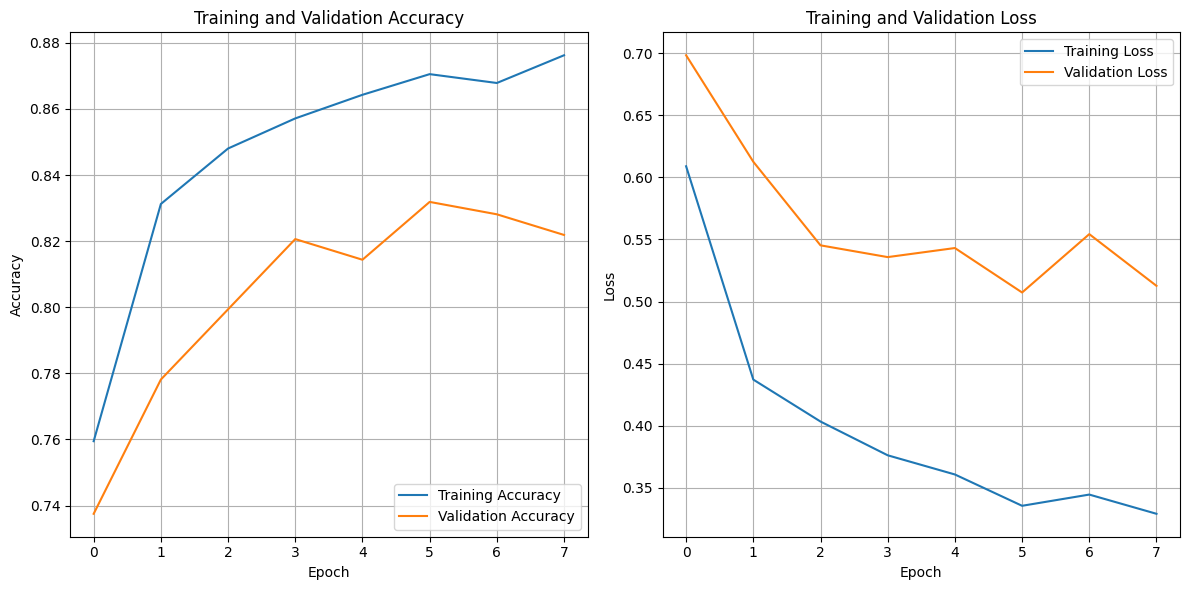

In [9]:
import matplotlib.pyplot as plt

# Get training and validation metrics from the history object
acc = history_phase1.history['accuracy']
val_acc = history_phase1.history['val_accuracy']

loss = history_phase1.history['loss']
val_loss = history_phase1.history['val_loss']

# Correctly determine the number of epochs that actually ran
epochs_range = range(len(acc)) # Use len(acc) to get the actual number of completed epochs

plt.figure(figsize=(12, 6))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
import tensorflow as tf
import os

# Re-define test_ds to ensure it's available in this scope.
# Using IMAGE_SIZE and BATCH_SIZE from the current kernel state for compatibility with the model.
# dataset_root is also expected to be available from previous cells.
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'Testing'),
    labels='inferred',
    label_mode='categorical',
    image_size=IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Optimize the test dataset for performance
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Evaluate the model on the test dataset
# Note: 'model' at this point refers to the fine-tuned transfer learning model (MobileNetV2).
loss_transfer_learning_test, accuracy_transfer_learning_test = model.evaluate(test_ds)

print(f"Test Loss (Fine-tuned Transfer Learning Model): {loss_transfer_learning_test:.4f}")
print(f"Test Accuracy (Fine-tuned Transfer Learning Model): {accuracy_transfer_learning_test * 100:.2f}%")

Found 1600 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8281 - loss: 0.5106
Test Loss (Fine-tuned Transfer Learning Model): 0.5106
Test Accuracy (Fine-tuned Transfer Learning Model): 82.81%


### <span style="color:blue;">Improving Model Accuracy: Transition to Transfer Learning & Fine-tuning</span>

Initially, we discussed various strategies to improve model accuracy. We've successfully implemented **Transfer Learning** using MobileNetV2, which significantly boosted our model's performance to over 80% accuracy by training only the custom classification head.

To push the accuracy even higher, especially towards our goal of 90%, the next logical step is **Fine-tuning**. This involves unfreezing a portion of the pre-trained base model's layers and training them alongside the custom head with a very small learning rate. This allows the model to adapt the pre-trained features more specifically to our brain MRI dataset, rather than just using them as generic feature extractors. This is a powerful technique to achieve state-of-the-art results on image classification tasks with limited datasets.

### Implementing Transfer Learning and Fine-tuning with MobileNetV2

We leverage a pre-trained MobileNetV2 model, initially freezing its base layers and attaching a custom classification head. After training the head, we proceed to **fine-tuning**, where we unfreeze a portion of the base model's layers and continue training with a very low learning rate. This strategy maximizes the model's ability to learn specific features from our brain MRI dataset.

### Correcting the Fine-tuning Process: Starting from the 82.81% Model

As we've observed, the previous attempt at fine-tuning led to a significant drop in accuracy. This was due to an unintentional re-initialization of the model with a different data pipeline. Our goal is to improve upon the already successful model that achieved **82.81% accuracy** during its initial head training. We will load that model, unfreeze its base layers, and apply proper fine-tuning to push the accuracy even higher, aiming for 90%.

In [25]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
from tensorflow.keras.applications import mobilenet_v2 # Import mobilenet_v2 for preprocess_input

print("--- Loading the best model from initial head training (82.81% accuracy) ---")

# Load the best model saved during the previous head training phase
# This model achieved 82.81% accuracy on the test set.
# Pass custom_objects to handle the Lambda layer with preprocess_input
model_for_fine_tuning = load_model(
    'best_mobilenet_model.keras',
    custom_objects={'preprocess_input': mobilenet_v2.preprocess_input}
)

model_for_fine_tuning.summary()
print("Model loaded successfully. Proceeding with fine-tuning.")

# Identify the base_model within the loaded model structure
# Assuming the base model is the second layer if the first is the Lambda layer.
if isinstance(model_for_fine_tuning.layers[1], tf.keras.Model):
    base_model_loaded = model_for_fine_tuning.layers[1]
else:
    # Fallback if structure is different (e.g., if Lambda layer is absent or embedded differently)
    # This part might need adjustment based on exact model structure if the above fails
    print("Could not directly find base_model as model.layers[1]. Attempting to find MobileNetV2 layer.")
    for layer in model_for_fine_tuning.layers:
        if isinstance(layer, tf.keras.Model) and 'MobileNetV2' in layer.name:
            base_model_loaded = layer
            break
    else:
        raise ValueError("MobileNetV2 base model not found in loaded model structure.")

print(f"Found base model: {base_model_loaded.name}")

# --- Unfreezing layers for true fine-tuning ---
# Unfreeze a portion of the base model for fine-tuning.
# It's common to unfreeze the top layers. MobileNetV2 has 154 layers.
# Let's unfreeze the last ~30-50 layers of the base model.
fine_tune_from_layer = 100 # Example: Unfreeze from layer 100 onwards (adjust as needed)

# Freeze all layers in the base model first, then unfreeze the desired portion
for layer in base_model_loaded.layers:
    layer.trainable = False

for i, layer in enumerate(base_model_loaded.layers):
    if i >= fine_tune_from_layer:
        layer.trainable = True

# Also ensure the classification head layers are trainable
for layer in model_for_fine_tuning.layers:
    # Only make classification head layers trainable, exclude the Lambda and base_model
    if not isinstance(layer, tf.keras.layers.Lambda) and layer.name != base_model_loaded.name:
        layer.trainable = True

print(f"Layers from {base_model_loaded.name} unfrozen from layer {fine_tune_from_layer} onwards.")

# --- Recompile the model with a very low learning rate ---
fine_tune_learning_rate = 0.00001 # A very small learning rate for fine-tuning

model_for_fine_tuning.compile(
    optimizer=optimizers.Adam(learning_rate=fine_tune_learning_rate),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

model_for_fine_tuning.summary()
print("Model re-compiled with unfrozen layers and a very low learning rate for fine-tuning.")

# --- Continue training (fine-tuning) ---
EPOCHS_FINE_TUNE_ACTUAL = 30 # Number of epochs for this fine-tuning phase

print(f"Starting actual fine-tuning for {EPOCHS_FINE_TUNE_ACTUAL} epochs...")

# We will reuse the early_stopping_callback defined previously
# The train_generator and validation_generator are from ImageDataGenerator and are optimal for this model.
history_fine_tune_actual = model_for_fine_tuning.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FINE_TUNE_ACTUAL,
    callbacks=[early_stopping_callback],
    verbose=1
)

print("Actual fine-tuning complete!")

--- Loading the best model from initial head training (82.81% accuracy) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751,438 (10.50 MB)

 Trainable params: 164,484 (642.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 2,025,924 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

Model re-compiled with unfrozen layers and a very low learning rate for fine-tuning.
Starting actual fine-tuning for 30 epochs...
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 113s 531ms/step - accuracy: 0.7455 - loss: 0.6964 - val_accuracy: 0.8056 - val_loss: 0.8592
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 501ms/step - accuracy: 0.8386 - loss: 0.4153 - val_accuracy: 0.8044 - val_loss: 0.8548
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 89s 506ms/step - accuracy: 0.8618 - loss: 0.3636 - val_accuracy: 0.8206 - val_loss: 0.7411
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 500ms/step - accuracy: 0.8777 - loss: 0.3235 - val_accuracy: 0.8250 - val_loss: 0.7182
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 505ms/step - accuracy: 0.8895 - loss: 0.2896 - val_accuracy: 0.8419 - val_loss: 0.6468
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 502ms/step - accuracy: 0.8959 - loss: 0.2803 - val_accuracy: 0.8438 - val_loss: 0.5987
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 89s 507ms/step - accuracy: 0.9070 - loss: 0

### Visualizing Combined Performance (Initial Head Training + Actual Fine-tuning)

This section illustrates the model's learning progression across both training phases. The plot visually represents how accuracy and loss evolved during the initial head training and the subsequent fine-tuning of the MobileNetV2 base.

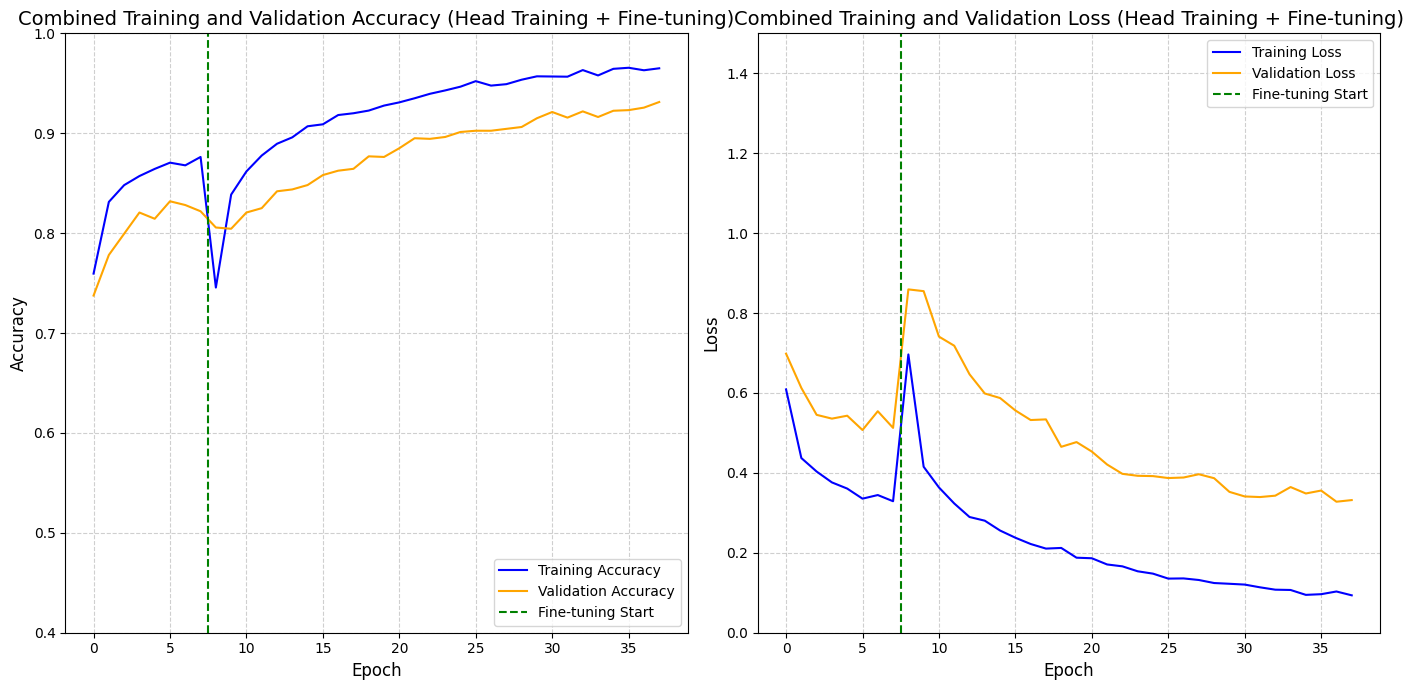

In [26]:
import matplotlib.pyplot as plt

# Retrieve history from the initial head training (history_phase1) and the actual fine-tuning
acc_initial_head = history_phase1.history['accuracy']
val_acc_initial_head = history_phase1.history['val_accuracy']

loss_initial_head = history_phase1.history['loss']
val_loss_initial_head = history_phase1.history['val_loss']

acc_fine_tune = history_fine_tune_actual.history['accuracy']
val_acc_fine_tune = history_fine_tune_actual.history['val_accuracy']

loss_fine_tune = history_fine_tune_actual.history['loss']
val_loss_fine_tune = history_fine_tune_actual.history['val_loss']

# Combine the histories
acc_combined_final = acc_initial_head + acc_fine_tune
val_acc_combined_final = val_acc_initial_head + val_acc_fine_tune
loss_combined_final = loss_initial_head + loss_fine_tune
val_loss_combined_final = val_loss_initial_head + val_loss_fine_tune

epochs_combined_final = range(len(acc_combined_final))

plt.figure(figsize=(14, 7))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_combined_final, acc_combined_final, label='Training Accuracy', color='blue')
plt.plot(epochs_combined_final, val_acc_combined_final, label='Validation Accuracy', color='orange')
plt.axvline(x=len(acc_initial_head) - 0.5, color='green', linestyle='--', label='Fine-tuning Start')
plt.ylim([0.4, 1.0])
plt.legend(loc='lower right')
plt.title('Combined Training and Validation Accuracy (Head Training + Fine-tuning)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_combined_final, loss_combined_final, label='Training Loss', color='blue')
plt.plot(epochs_combined_final, val_loss_combined_final, label='Validation Loss', color='orange')
plt.axvline(x=len(acc_initial_head) - 0.5, color='green', linestyle='--', label='Fine-tuning Start')
plt.ylim([0.0, max(max(loss_combined_final), max(val_loss_combined_final), 1.5)])
plt.legend(loc='upper right')
plt.title('Combined Training and Validation Loss (Head Training + Fine-tuning)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Final Evaluation on the Test Dataset (After Actual Fine-tuning)

After completing both the initial head training and the fine-tuning phases, we perform a final evaluation of the model on the unseen test dataset (`test_generator`). This provides an unbiased measure of the fine-tuned model's generalization capabilities and its overall accuracy on new brain MRI scans.

In [27]:
loss_final_fine_tune_test, accuracy_final_fine_tune_test = model_for_fine_tuning.evaluate(test_generator)

print(f"Test Loss (Fully Fine-tuned Model): {loss_final_fine_tune_test:.4f}")
print(f"Test Accuracy (Fully Fine-tuned Model): {accuracy_final_fine_tune_test * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9256 - loss: 0.3278
Test Loss (Fully Fine-tuned Model): 0.3278
Test Accuracy (Fully Fine-tuned Model): 92.56%
